# Baseline — Regressão Linear

Modelo mais simples do estudo comparativo. Mesmos dados/split/CV do `data_prep` (`FarmStratifiedSplit`, 5 folds de 49 de teste por fazenda) e o mesmo `leave_one_property_out`, via `sk_eval` — comparação justa com a DNN.

## 1. Setup

In [1]:
import os, sys
while not os.path.isdir("support_scripts"):
    os.chdir("..")
sys.path.append("support_scripts")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import data_prep as dp
import sk_eval

## 2. Dados

In [2]:
d = dp.get_data()
df, groups = d["df"], d["groups"]
print(f"{len(df)} animais | {len(d['feature_cols'])} preditores")
print("grupos:", groups.value_counts().to_dict())

245 animais | 9 preditores
grupos: {'elvis': 174, 'humberto': 71}


## 3. CV + LOPO (via `sk_eval`)

Linear precisa de `scale=True` (StandardScaler fit só no treino, dentro do pipeline). Roda com e sem jitter; `registrar` grava o melhor dos dois em `results/model_comparison.csv`.

In [3]:
res = sk_eval.registrar("Linear", lambda: LinearRegression(), scale=True, d=d)
res["sem_jitter"].agg(["mean", "std"]).round(4)

Linear: CV R2 sem=0.426 / com jitter=0.425  | MAE=0.0626
  LOPO R2: {'elvis': -70.96, 'humberto': -1.61}


,MAE,RMSE,R2
mean,0.0629,0.0830,0.4260
std,0.0063,0.0119,0.3525


In [4]:
print("LOPO (treina 1 fazenda, testa a outra):")
res["lopo"]

LOPO (treina 1 fazenda, testa a outra):


,testa,MAE,RMSE,R2
0,elvis,0.3504,0.7327,-70.9556
1,humberto,0.2490,0.2698,-1.6082


## 4. Predito × real (OOF)

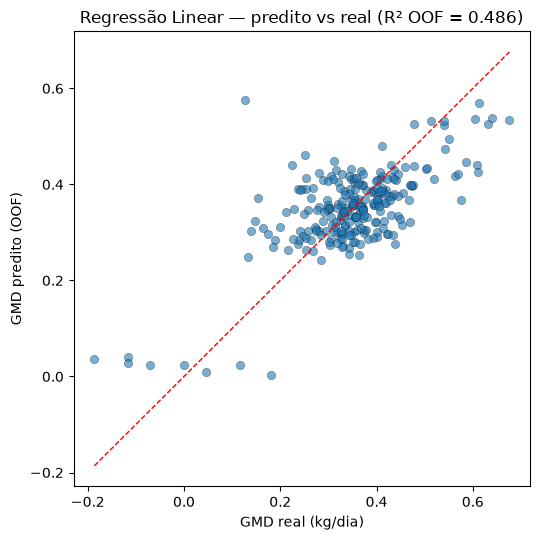

In [5]:
y_true = df[dp.TARGET].values
y_oof = sk_eval.oof(d, lambda: LinearRegression(), scale=True)
r2_oof = dp.metrics(y_true, y_oof)["R2"]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true, y_oof, alpha=0.6, edgecolor="k", linewidth=.3)
lims = [min(y_true.min(), y_oof.min()), max(y_true.max(), y_oof.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("GMD real (kg/dia)"); ax.set_ylabel("GMD predito (OOF)")
ax.set_title(f"Regressão Linear — predito vs real (R² OOF = {r2_oof:.3f})")
plt.tight_layout(); plt.show()

## 5. Notas

- Mesmo `get_cv()`/`leave_one_property_out` da DNN — comparação direta em `results/model_comparison.csv`.
- Não escala automaticamente com a complexidade do sinal; serve de piso de referência para os modelos seguintes (XGBoost, TabPFN, DNN).